In [1]:
import json
import warnings
import emoji
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import scikit_posthocs as sp
import seaborn as sns
from pymongo import MongoClient
from scipy.stats import kruskal, spearmanr
from nltk.util import ngrams
from wordcloud import WordCloud


warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 100)
%matplotlib inline

## Loading customer review dataset

In [2]:
def read_collection() -> pd.DataFrame:
    """
    Reads all records from the configured MongoDB collection and returns them as a pandas DataFrame.
    The MongoDB connection details: database name and collection name are read from the config.json file.

    @returns:
        pd.DataFrame: Pandas DataFrame containing all records retrieved from the MongoDB collection.
    """
    # Reading configurations file to extract database name and collection names
    with open("config.json", "r") as file:
        config_data = json.load(file)

    # Establishing connection with MongoDB & reading customer reviews
    client = MongoClient(config_data['mongo_url'])
    db = client[config_data['database_name']]
    collection = db[config_data['collection_name']]
    records = list(collection.find({}))

    return pd.DataFrame(records)

In [3]:
# Importing dataset
raw_df = read_collection()
raw_df.head()

,_id,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,6a8093e50150837abb470a75,8fe7e2d3-e2fa-4eed-9cb8-d1a22378c7d7,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,one of the worst payment and refund system the...,1,0,None,2026-08-14 21:57:33,"Hi there, extremely sorry for the kind of expe...",2026-08-14 22:09:36,None
1,6a8093e50150837abb470a76,754a62b3-ccc3-4648-8dc6-f463f6a2f025,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,very good sir,5,0,18.19.0,2026-08-14 21:57:16,"Hi there, thank you for the brightening 5 star...",2026-08-14 22:03:41,18.19.0
2,6a8093e50150837abb470a77,ff198273-30a2-4e46-b92f-0be0f4af1a2e,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"Very nice app, am amazing, really delive.The i...",5,0,None,2026-08-14 21:56:33,"Hi there, thank you for the brightening 5 star...",2026-08-14 22:03:39,None
3,6a8093e50150837abb470a78,11d2502d-8846-4c6f-b869-e15245c9b755,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,very useful,5,0,18.15.0,2026-08-14 21:56:08,"Hi there, thank you for the brightening 5 star...",2026-08-14 22:03:38,18.15.0
4,6a8093e50150837abb470a79,37f7b890-601c-481f-a329-191e5227faf4,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,poor service,2,0,18.15.0,2026-08-14 21:55:21,"Hi there, extremely sorry for the kind of expe...",2026-08-14 22:06:33,18.15.0


## Exploratory Data Analysis

In [4]:
# Checking shape of raw data
raw_df.shape

(100000, 12)

In [5]:
# Fetching information about the dataset
raw_df.info()
# Certain columns have to undergo corrections in data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   _id                   100000 non-null  object        
 1   reviewId              100000 non-null  object        
 2   userName              100000 non-null  object        
 3   userImage             100000 non-null  object        
 4   content               100000 non-null  object        
 5   score                 100000 non-null  int64         
 6   thumbsUpCount         100000 non-null  int64         
 7   reviewCreatedVersion  87326 non-null   object        
 8   at                    100000 non-null  datetime64[ns]
 9   replyContent          98461 non-null   object        
 10  repliedAt             98461 non-null   datetime64[ns]
 11  appVersion            87326 non-null   object        
dtypes: datetime64[ns](2), int64(2), object(8)
memory usage: 9.2

In [6]:
# Checking for missing values
raw_df.isnull().sum()

_id                         0
reviewId                    0
userName                    0
userImage                   0
content                     0
score                       0
thumbsUpCount               0
reviewCreatedVersion    12674
at                          0
replyContent             1539
repliedAt                1539
appVersion              12674
dtype: int64

In [7]:
# Determining duplicate records. Since, reviewID is the primary key of the table, we will be using that to determine duplicates.
original_records = len(raw_df['reviewId'].values)
dropped_duplicates_records = len(raw_df['reviewId'].drop_duplicates().values)
num_duplicates = original_records - dropped_duplicates_records
print(f'Original number of reviewIDs : {original_records}')
print(f'Number of reviewIDs after dropping duplicates : {dropped_duplicates_records}')
print(f'Number of duplicated reviewIDs : {num_duplicates}')

Original number of reviewIDs : 100000
Number of reviewIDs after dropping duplicates : 100000
Number of duplicated reviewIDs : 0


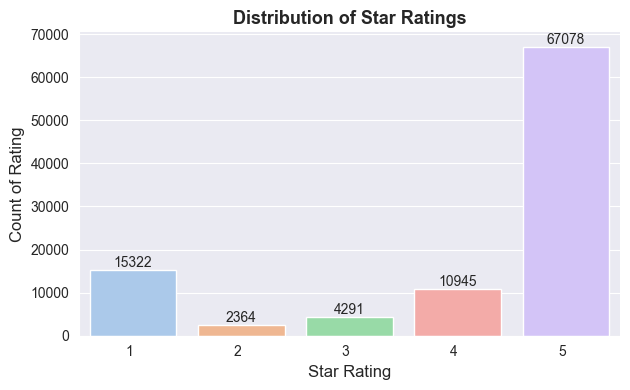

In [8]:
# Plotting distribution of score feature across all reviews
with sns.axes_style('darkgrid'):
    plot = sns.catplot(x ="score", data = raw_df, kind="count", height=4, aspect=1.6, palette="pastel", legend=False, hue = "score")
    plt.title("Score Distribution")
    ax = plot.axes[0,0]
    for p in ax.patches:
        count = int(p.get_height())
        ax.annotate(
            str(count), 
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha='center', va='bottom'
        )
    
    plt.title("Distribution of Star Ratings", fontsize=13, fontweight="bold")
    plt.ylabel("Count of Rating", fontsize=12)
    plt.xlabel("Star Rating", fontsize=12)
    plt.xticks(rotation=0, ha="right")
    plt.tight_layout()
    plt.show()

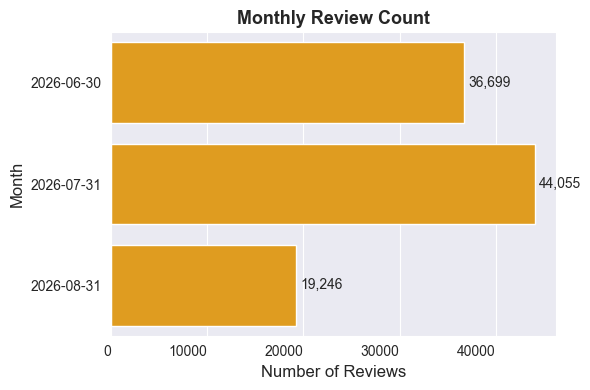

In [9]:
# # Converting 'at' and 'repliedAt' columns to datetime format
raw_df['at_converted'] = pd.to_datetime(pd.to_datetime(raw_df["at"]).dt.date)
raw_df["repliedAt_converted"] = pd.to_datetime(pd.to_datetime(raw_df["repliedAt"]).dt.date)

# Resampling the data to get monthly review counts
monthly_review_count = (raw_df.set_index('at_converted').resample('ME').size().reset_index(name='Review Count'))

with sns.axes_style("darkgrid"):
    plt.figure(figsize=(6, 4))

    ax = sns.barplot(data = monthly_review_count, y = "at_converted", x = "Review Count", color="orange", orientation="horizontal")

    # Add data labels
    for container in ax.containers:
        ax.bar_label(container, fmt='{:,.0f}', padding=3, fontsize = 10) # type: ignore

    plt.title("Monthly Review Count", fontsize=13, fontweight="bold")
    plt.ylabel("Month", fontsize=12)
    plt.xlabel("Number of Reviews", fontsize=12)
    plt.xticks(rotation=0, ha="right")
    plt.tight_layout()
    plt.show()

#### Exploratory Data Analysis - RepliedAt vs At (Response Time Analysis)

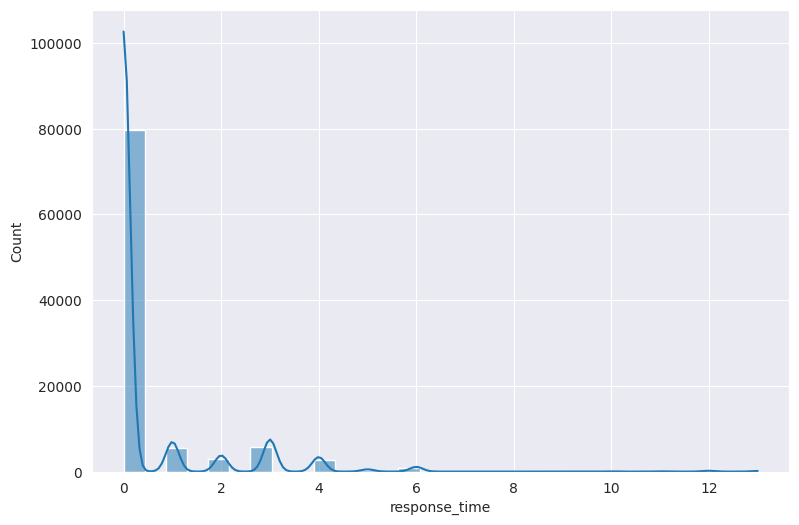

In [10]:
# Exploring more about the response time 
raw_df['response_time'] = (pd.to_datetime(raw_df['repliedAt_converted']) - pd.to_datetime(raw_df['at_converted'])).dt.days
temp_df = raw_df[raw_df['response_time'] >= 0]
with sns.axes_style("darkgrid"):
    plt.figure(figsize=(9, 6))
    sns.histplot(data = temp_df, x = 'response_time', bins = 30, kde=True)

# The distribution of the response time is right skewed, with most of the responses being sent within 0-10 days. However, there are some outliers where the response time is more than 20 days. 
# This could be due to various reasons such as the review being missed or delayed in response.

In [11]:
# Analyzing the response time based on the score of the review
score_response_time = temp_df.groupby("score")["response_time"].agg(
    ["count", "mean", "median", "std"]
)
score_response_time

,count,mean,median,std
score,,,,
1,14787,0.715629,0.0,1.555137
2,2246,1.275156,0.0,1.923938
3,3995,2.560200,2.0,2.107779
4,10505,1.654260,1.0,1.808793
5,66577,0.140274,0.0,0.753516


Spearman Correlation
Spearman Correlation (ρ) : -0.4388
Spearman p-value         : 0.00000


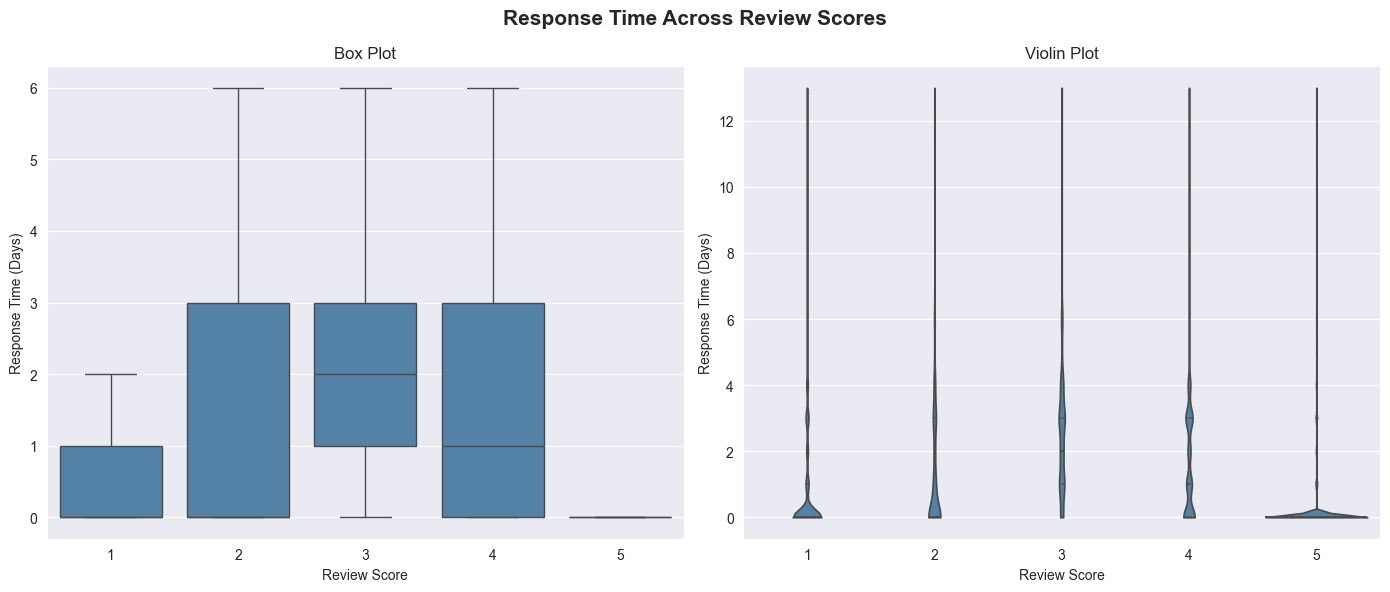

In [12]:
# Determing the correlation between Response Time vs Score of Review using Spearman Correlation
rho, p_corr = spearmanr(temp_df["score"], temp_df["response_time"])
print("="*50)
print("Spearman Correlation")
print("="*50)
print(f"Spearman Correlation (ρ) : {rho:.4f}")
print(f"Spearman p-value         : {p_corr:.5f}")

# Spearman Correlation: A moderate negative correlation (ρ = -0.4388) exists between the variables, and the relationship is statistically significant (p < 0.001).
with sns.axes_style("darkgrid"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Box Plot
    sns.boxplot(data = temp_df, x = "score", y = "response_time", showfliers = False, color = "steelblue", ax = axes[0])
    axes[0].set_title("Box Plot")
    axes[0].set_xlabel("Review Score")
    axes[0].set_ylabel("Response Time (Days)")

    # Violin Plot
    sns.violinplot(data = temp_df, x = "score", y = "response_time", inner = "quartile", color = "steelblue", cut = 0, ax = axes[1])
    axes[1].set_title("Violin Plot")
    axes[1].set_xlabel("Review Score")
    axes[1].set_ylabel("Response Time (Days)")

    plt.suptitle("Response Time Across Review Scores", fontsize = 15, fontweight = "bold")
    plt.tight_layout()
    plt.show()

# The box and violin plots show that 5-star reviews receive the fastest responses, while 3-star and 4-star reviews experience comparatively longer response times. 
# However, this pattern is largely influenced by the widespread use of standardized acknowledgement templates for 5-star reviews, which substantially reduce their average response time.

In [13]:
# Performing Kruskal-Wallis Test: Non-Parametric Test used in order to compare three or more independent groups to determine if there are statistically significant differences between them.

# Null Hypothesis : The distribution of response time is the same across all review-score groups (1, 2, 3, 4, and 5).
# Alternate Hypothesis : At least one review-score group has a different distribution of response time.
groups = [group["response_time"].dropna() for _, group in temp_df.groupby("score")]
H, p_kw = kruskal(*groups)
print("="*50)
print("Kruskal-Wallis Test")
print("="*50)
print(f"Kruskal-Wallis H         : {H:.4f}")
print(f"Kruskal-Wallis p-value   : {p_kw:.5f}")

if p_kw < 0.05:
    print('Since P-Value is less than significance level, we reject the null hypothesis. Thus, atleast 1 review-score group has a different distribution of response time.')
else:
    print('Since P-Value is greater than significance level, we failt to reject the null hypothesis. Thus, distribution of response time is same across all review-score groups.')

print("="*50)

# Kruskal-Wallis Test: There is a statistically significant difference in the distributions of the variable across the groups (H = 35,417.33, p < 0.001).
# The Kruskal-Wallis Test does not indicate which group differs significantly, therefore, we will have to perform Dunn's Test with Bonferroni Correction

Kruskal-Wallis Test
Kruskal-Wallis H         : 35417.3289
Kruskal-Wallis p-value   : 0.00000
Since P-Value is less than significance level, we reject the null hypothesis. Thus, atleast 1 review-score group has a different distribution of response time.


              1             2              3              4    5
1  1.000000e+00  3.303393e-92   0.000000e+00   0.000000e+00  0.0
2  3.303393e-92  1.000000e+00   0.000000e+00   8.427460e-78  0.0
3  0.000000e+00  0.000000e+00   1.000000e+00  2.267492e-248  0.0
4  0.000000e+00  8.427460e-78  2.267492e-248   1.000000e+00  0.0
5  0.000000e+00  0.000000e+00   0.000000e+00   0.000000e+00  1.0


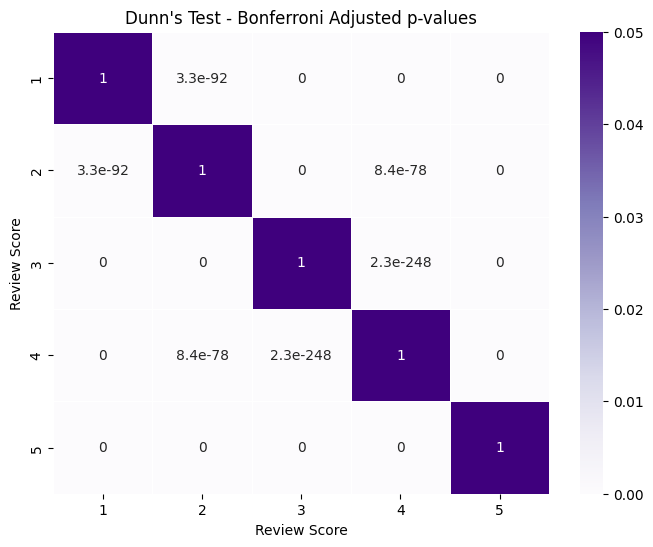

In [14]:
# Dunn's test is a post-hoc non-parametric test used after a significant Kruskal–Wallis test to determine which specific groups are significantly different from each other.
# When multiple statistical testsare performed,  the probability of getting at least one false significant result increases. For example, with 10 independent comparisons, 
# the probability of getting at least one false positive can become substantially larger than 5%. Bonferroni Correction makes the significance criterion more conservative using the formula 
# a(adj) = a/m   ; (a -> significance level 0.05 & m -> number of comparisons (10))

dunn_results = sp.posthoc_dunn(raw_df, val_col = "response_time", group_col = "score", p_adjust = "bonferroni")
print(dunn_results)

plt.figure(figsize=(8, 6))
sns.heatmap(dunn_results, annot = True, cmap = "Purples", linewidth = 0.5, vmin = 0, vmax = 0.05)
plt.title("Dunn's Test - Bonferroni Adjusted p-values")
plt.xlabel("Review Score")
plt.ylabel("Review Score")
plt.show();

# The Kruskal–Wallis test confirmed significant differences in response-time distributions across review scores (H = 35,417.33, p < 0.001), while Dunn's post-hoc analysis showed that 
# every pair of rating groups differed significantly after Bonferroni correction.

In [15]:
# Determining the summary statistics of the response times to see what the differences actually look like
summary = raw_df.groupby("score")["response_time"].agg(
    count = "count",
    median = "median",
    mean = "mean",
    std = "std",
    min = "min",
    max = "max"
)
summary
# Response-time distribution is highly skewed, with long tails. For example, a few responses taking 10–13 days can substantially increase the mean. The median is much less affected by those extreme observations.

,count,median,mean,std,min,max
score,,,,,,
1,14862,0.0,-0.175414,24.010946,-1474.0,13.0
2,2253,0.0,-0.367954,39.348152,-1456.0,13.0
3,4006,2.0,1.714928,26.282545,-1205.0,13.0
4,10530,1.0,1.240456,15.478953,-1153.0,13.0
5,66810,0.0,-0.370019,17.167574,-1425.0,13.0


In [16]:
# Which rating tends to have higher response times
raw_df["response_time_rank"] = raw_df["response_time"].rank()
mean_ranks = (raw_df.groupby("score")["response_time_rank"].mean().sort_index())
mean_ranks

score
1    52631.765173
2    62008.730803
3    83524.178857
4    70844.127018
5    42580.871254
Name: response_time_rank, dtype: float64

In [17]:
# Checking the percentage of 0 ratings 
zero_response = (raw_df.groupby("score")["response_time"].apply(lambda x: (x == 0).mean() * 100).rename("zero_response_percentage"))
zero_response

score
1    71.602924
2    52.749577
3    11.186204
4    35.523070
5    94.179910
Name: zero_response_percentage, dtype: float64

In [18]:
# Aggregating all statistics together
analysis_summary = raw_df.groupby("score").agg(
    count=("response_time", "count"),
    median_response_time=("response_time", "median"),
    mean_response_time=("response_time", "mean"),
    std_response_time=("response_time", "std"),
    zero_response_percentage=(
        "response_time",
        lambda x: (x == 0).mean() * 100
    ),
    mean_rank=("response_time_rank", "mean")
)

analysis_summary

,count,median_response_time,mean_response_time,std_response_time,zero_response_percentage,mean_rank
score,,,,,,
1,14862,0.0,-0.175414,24.010946,71.602924,52631.765173
2,2253,0.0,-0.367954,39.348152,52.749577,62008.730803
3,4006,2.0,1.714928,26.282545,11.186204,83524.178857
4,10530,1.0,1.240456,15.478953,35.523070,70844.127018
5,66810,0.0,-0.370019,17.167574,94.179910,42580.871254


In [19]:
# Isolating the Non-Zero response times to study them separately
df_nonzero = raw_df[raw_df["response_time"] > 0]
nonzero_summary = df_nonzero.groupby("score")["response_time"].agg(
    count="count",
    median="median",
    mean="mean",
    std="std",
    min="min",
    max="max"
)
nonzero_summary

,count,median,mean,std,min,max
score,,,,,,
1,3816,3.0,2.773061,1.914795,1.0,13.0
2,999,3.0,2.866867,1.938765,1.0,13.0
3,3515,3.0,2.909815,2.007981,1.0,13.0
4,6617,3.0,2.626266,1.625204,1.0,13.0
5,3403,3.0,2.744343,1.990688,1.0,13.0


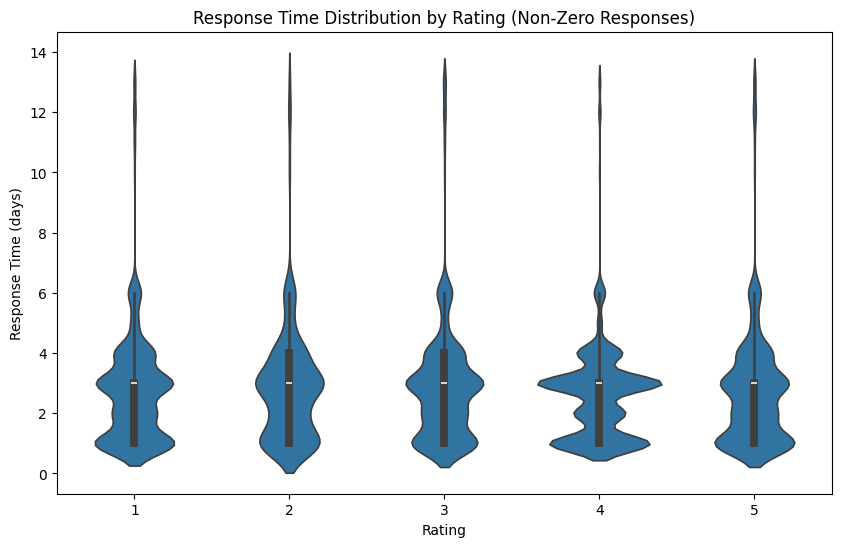

In [20]:
plt.figure(figsize=(10, 6))
sns.violinplot(data = df_nonzero, x = "score", y = "response_time")
plt.xlabel("Rating")
plt.ylabel("Response Time (days)")
plt.title("Response Time Distribution by Rating (Non-Zero Responses)")
plt.show()

In [21]:
df_nonzero.groupby("score")["response_time"].mean()

score
1    2.773061
2    2.866867
3    2.909815
4    2.626266
5    2.744343
Name: response_time, dtype: float64

`Review rating` is `significantly` associated with `response-time patterns (Spearman ρ = −0.4388, p < 0.001; Kruskal–Wallis H = 35,417.33, p < 0.001)`, with Dunn's post-hoc test showing `significant differences between all rating pairs after Bonferroni correction`. However, this difference is largely driven by the `dominating` 0 day responses. When these observations are excluded, the `median response time is 3 days` for every rating and mean response times vary only slightly `(2.63–2.91 days)`, indicating `no substantial relationship between rating and the actual duration of non-zero responses`.

#### Exploratory Data Analysis - 'content'

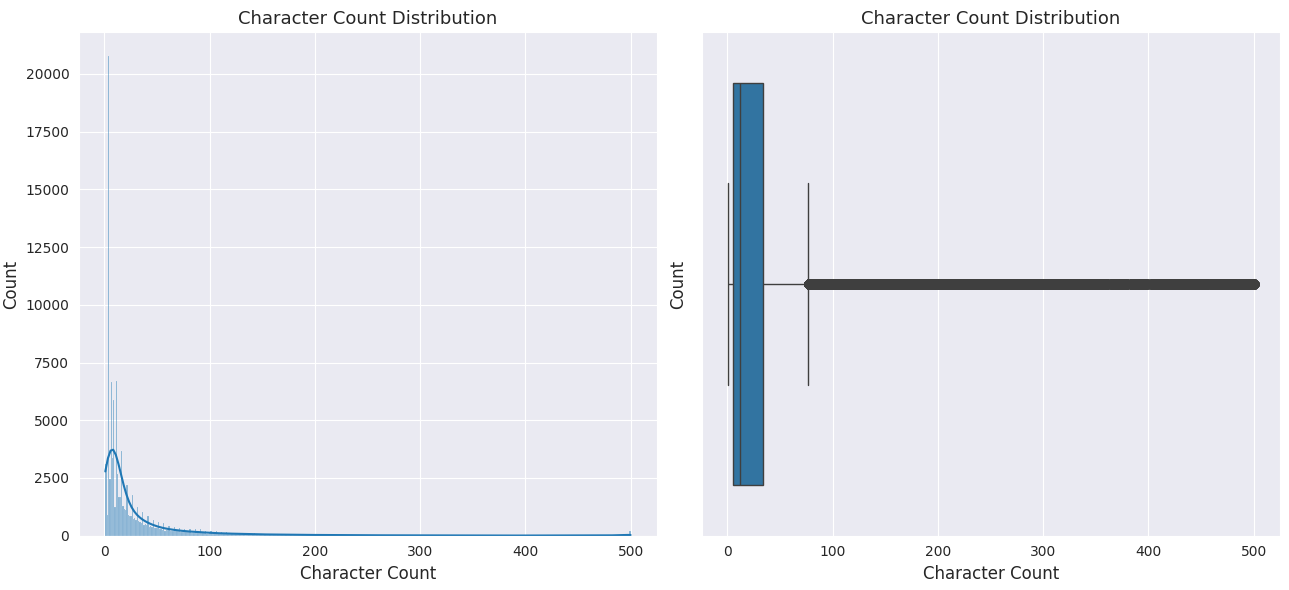

In [22]:
# Finding the character count for each review & plotting a histogram
raw_df["char_count"] = raw_df["content"].fillna("").str.len()

with sns.axes_style('darkgrid'):
    fig, ax = plt.subplots(1,2, figsize = (13,6))
    ax[0] = sns.histplot(data = raw_df, x = "char_count", kde = True, ax = ax[0])
    ax[0].set_title("Character Count Distribution",fontsize = 13)
    ax[0].set_xlabel("Character Count",fontsize=12)
    ax[0].set_ylabel("Count", fontsize=12)

    ax[1] = sns.boxplot(data = raw_df, x="char_count", ax = ax[1])
    ax[1].set_title("Character Count Distribution",fontsize = 13)
    ax[1].set_xlabel("Character Count",fontsize=12)
    ax[1].set_ylabel("Count", fontsize=12)
    fig.tight_layout()

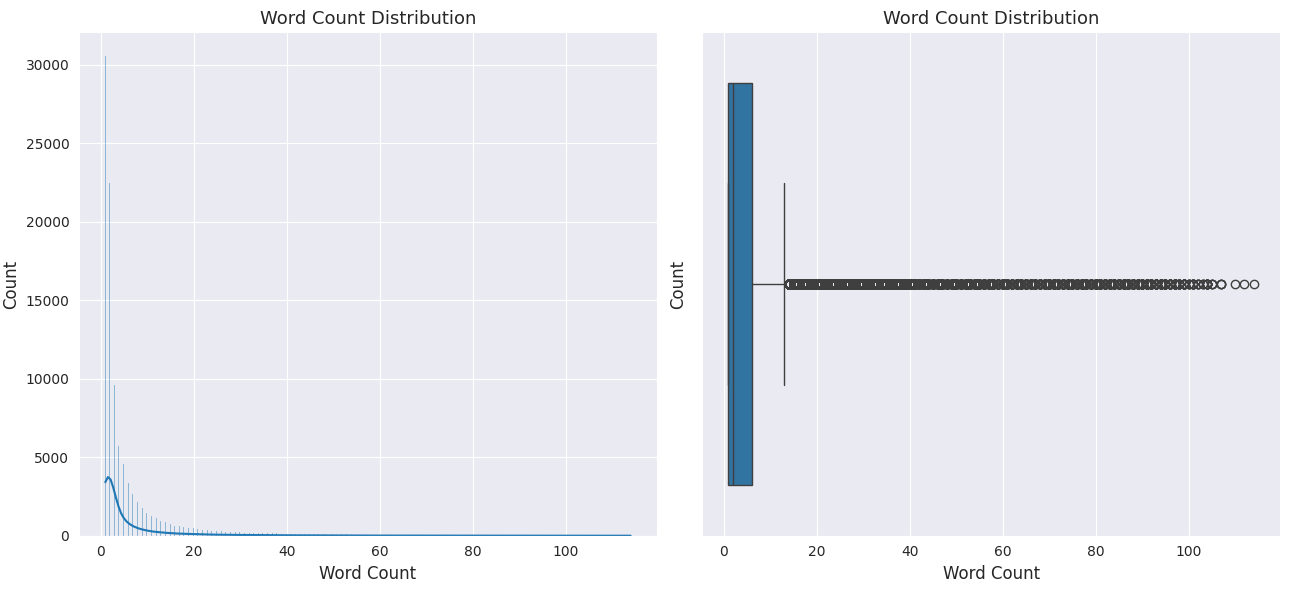

In [23]:
# Number of Words per review
raw_df['word_count'] = raw_df['content'].str.split().apply(lambda x: len(x))

# Finding the character count for each review & plotting a histogram
with sns.axes_style('darkgrid'):
    fig, ax = plt.subplots(1,2, figsize = (13,6))
    ax[0] = sns.histplot(data = raw_df, x = "word_count", kde = True, ax = ax[0])
    ax[0].set_title("Word Count Distribution",fontsize = 13)
    ax[0].set_xlabel("Word Count",fontsize=12)
    ax[0].set_ylabel("Count", fontsize=12)

    ax[1] = sns.boxplot(data = raw_df, x="word_count", ax = ax[1])
    ax[1].set_title("Word Count Distribution",fontsize = 13)
    ax[1].set_xlabel("Word Count",fontsize=12)
    ax[1].set_ylabel("Count", fontsize=12)
    fig.tight_layout()

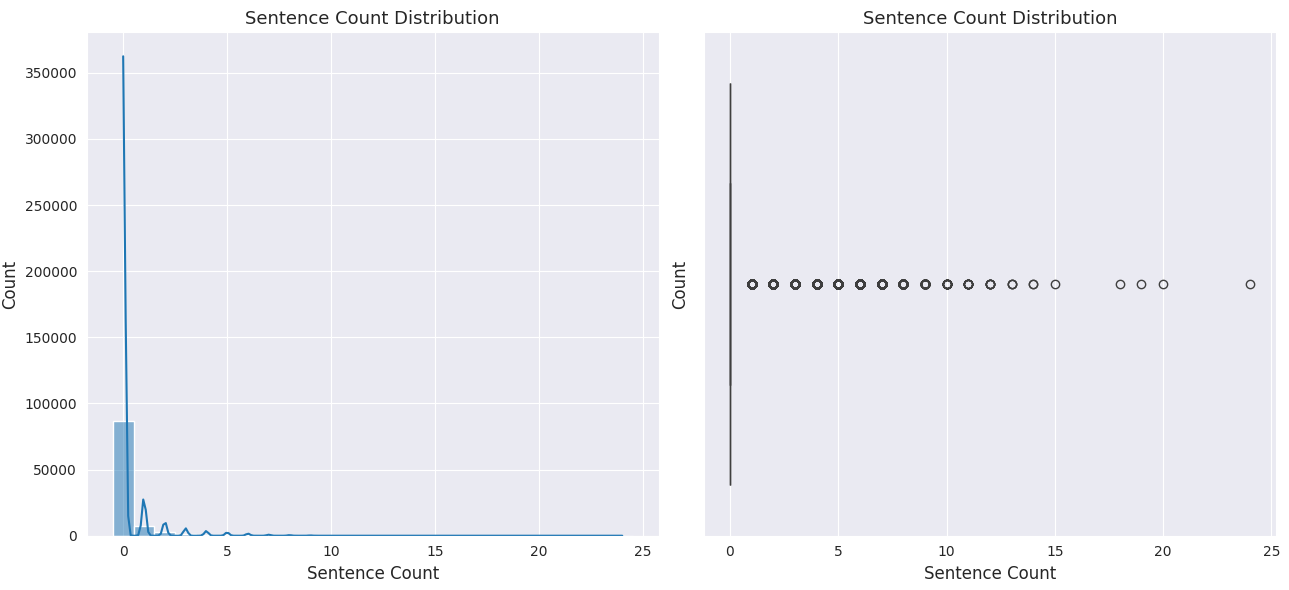

In [24]:
# Determining the sentence count
raw_df["sentence_count"] = (raw_df["content"].fillna("").str.count(r"[.!?]+"))

# Finding the character count for each review & plotting a histogram
with sns.axes_style('darkgrid'):
    fig, ax = plt.subplots(1,2, figsize = (13,6))
    ax[0] = sns.histplot(data = raw_df, x = "sentence_count", kde = True, ax = ax[0], discrete = True)
    ax[0].set_title("Sentence Count Distribution",fontsize = 13)
    ax[0].set_xlabel("Sentence Count",fontsize=12)
    ax[0].set_ylabel("Count", fontsize=12)

    ax[1] = sns.boxplot(data = raw_df, x="sentence_count", ax = ax[1])
    ax[1].set_title("Sentence Count Distribution",fontsize = 13)
    ax[1].set_xlabel("Sentence Count",fontsize=12)
    ax[1].set_ylabel("Count", fontsize=12)
    fig.tight_layout()

In [25]:
# Generating summary for character, word and sentence count
raw_df[["char_count", "word_count", "sentence_count"]].describe()

,char_count,word_count,sentence_count
count,100000.000000,100000.00000,100000.000000
mean,37.148850,6.87225,0.282090
std,70.830319,12.60406,0.955167
min,1.000000,1.00000,0.000000
25%,5.000000,1.00000,0.000000
50%,12.000000,2.00000,0.000000
75%,34.000000,6.00000,0.000000
max,500.000000,114.00000,24.000000


In [26]:
# Determining Summary Statistics based on score
raw_df.groupby(by = 'score')[["char_count", "word_count", "sentence_count"]].mean()

# Summary statistics shows an inverse relationship between the score and character, word & sentence count. 
# High scoring reviews have lesser words, characters and sentences on average than lower scoring reviews. 

,char_count,word_count,sentence_count
score,,,
1,102.599204,18.373972,0.904190
2,66.964467,12.233503,0.577834
3,42.591004,7.949662,0.317409
4,29.122156,5.567565,0.184742
5,22.109425,4.200036,0.143192


##### Token Analysis

In [27]:
# Generating vocabulary for identifying most frequently occuring tokens in the review body
def generate_vocabulary(input_column, df):
    """ 
    Function to build the vocabulary of reviews.

    @args:
        input_column: Pandas dataframe column name, which stores review body

    @returns:
        generated_vocabulary: Python list containing the vocabulary of the dataset
    
    """
    list_reviews = df[input_column].to_list()
    generated_vocabulary = []
    for review in list_reviews:
        words = review.lower().split()
        for word in words:
            generated_vocabulary.append(word)
    return generated_vocabulary

Number of tokens present in the vocabulary : 687225
Number of unique tokens in the vocabulary : 36505


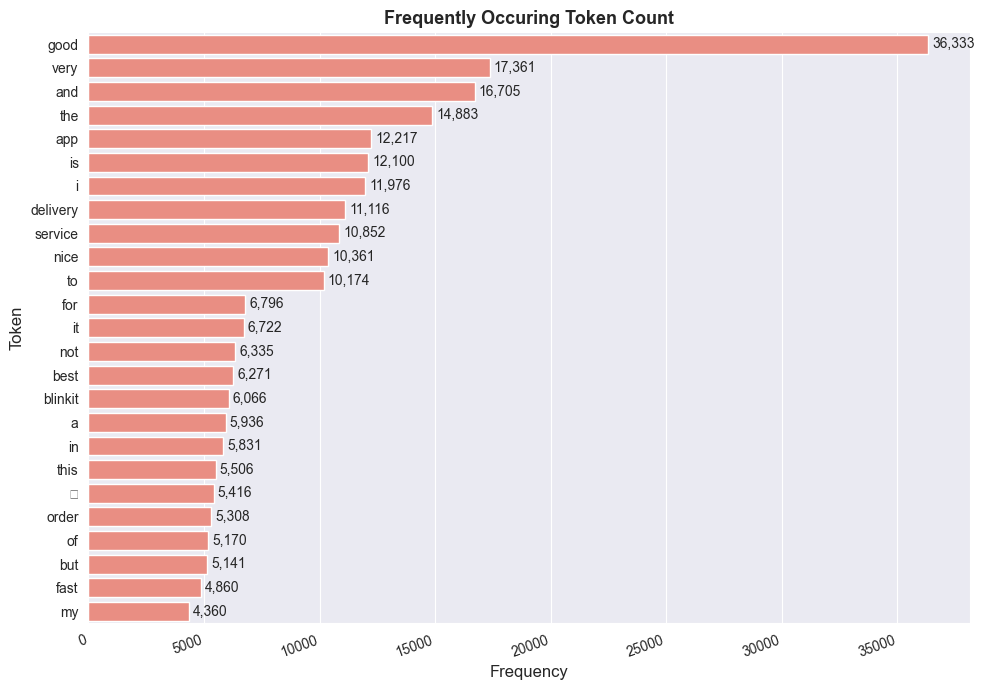

In [28]:
# Generating vocabulary for review body column
vocab = generate_vocabulary('content', raw_df)
print(f'Number of tokens present in the vocabulary : {len(vocab)}')
print(f'Number of unique tokens in the vocabulary : {len(set(vocab))}')

# Calculating occurance frequency of tokens & retrieving most frequently occuring tokens
word_counts = Counter(vocab)
most_frequent = word_counts.most_common(25)
token_labels = [most_frequent[i][0] for i in range(len(most_frequent))]
token_frequency = [most_frequent[i][1] for i in range(len(most_frequent))]



# Plotting frequency of most frequently occuring tokens
with sns.axes_style("darkgrid"):
    plt.figure(figsize=(10, 7))
    ax = sns.barplot(x = token_frequency, y = token_labels, color="salmon")

    # Add data labels
    for container in ax.containers:
        ax.bar_label(container, fmt='{:,.0f}', padding=3, fontsize = 10) # type: ignore

    plt.title("Frequently Occuring Token Count", fontsize = 13, fontweight = "bold")
    plt.ylabel("Token", fontsize = 12)
    plt.xlabel("Frequency", fontsize=12)
    plt.xticks(rotation = 20, ha = "right")
    plt.tight_layout()
    plt.show();

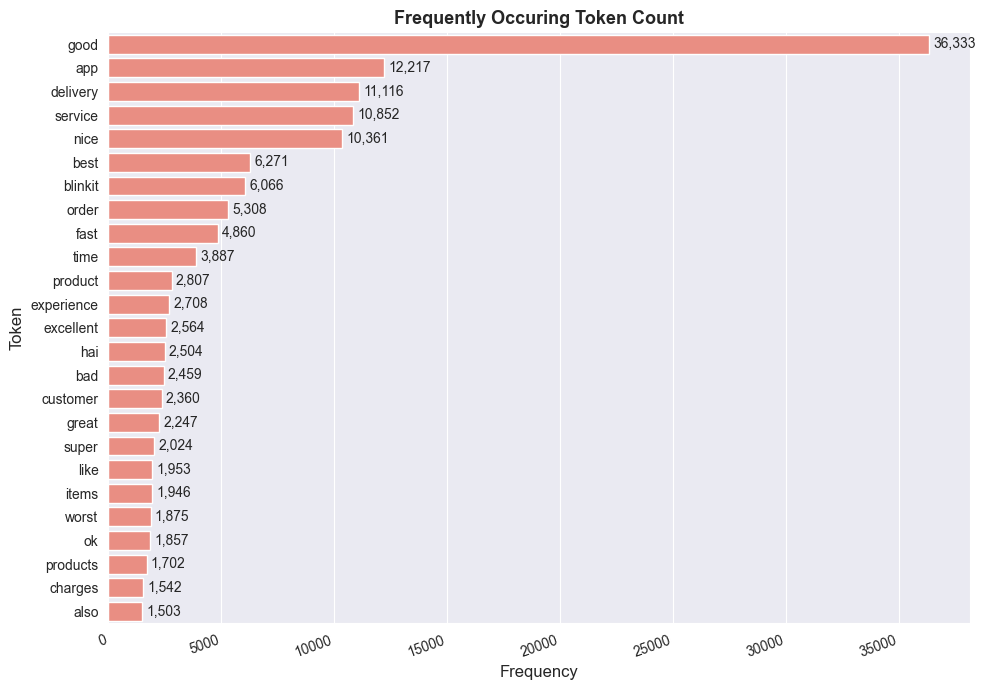

In [29]:
# The above graph contains multiple-stop words and emoticons. Removing the stopwords & emojis would provide some more meaningful insights in the most frequently occuring tokens
stop_words = [
    "i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you", "you're", "you've", "you'll", "you'd", "your", "yours", "yourself", "yourselves", "he", "him", "his", "himself", "she",
    "she's", "her", "hers", "herself", "it", "it's", "its", "itself", "they", "them", "their", "theirs", "themselves", "what", "which", "who", "whom", "this", "that", "that'll", "these", "those", "am",
    "is", "are", "was", "were", "be", "been", "being", "have", "has", "had", "having", "do", "does", "did", "doing", "a", "an", "the", "and", "but", "if", "or", "because", "as", "until", "while", "of",
    "at", "by", "for", "with", "about", "against", "between", "into", "through", "during", "before", "after", "above", "below", "to", "from", "up", "down", "in", "out", "on", "off", "over", "under",
    "again", "further", "then", "once", "here", "there", "when", "where", "why", "how", "all", "any", "both", "each", "few", "more", "most", "other", "some", "such", "no", "nor", "not", "only", "own",
    "same", "so", "than", "too", "very", "s", "t", "can", "will", "just", "don", "don't", "should", "should've", "now", "d", "ll", "m", "o", "re", "ve", "y", "ain", "aren", "aren't", "couldn",
    "couldn't", "didn", "didn't", "doesn", "doesn't", "hadn", "hadn't", "hasn", "hasn't", "haven", "haven't", "isn", "isn't", "ma", "mightn", "mightn't", "mustn", "mustn't", "needn", "needn't", "shan", "shan't",
    "shouldn", "shouldn't", "wasn", "wasn't", "weren", "weren't", "won't", "wouldn", "wouldn't"
]

# Filtering stopwords from vocabulary & fetching most frequently occuring tokens
stop_words = set(stop_words)
filtered_tokens = [token for token in vocab if token.lower() not in stop_words and not emoji.is_emoji(token)]
word_counts = Counter(filtered_tokens)
most_frequent = word_counts.most_common(25)
token_labels = [most_frequent[i][0] for i in range(len(most_frequent))]
token_frequency = [most_frequent[i][1] for i in range(len(most_frequent))]


# Plotting
with sns.axes_style("darkgrid"):
    plt.figure(figsize=(10, 7))
    ax = sns.barplot(x = token_frequency, y = token_labels, color="salmon")

    # Add data labels
    for container in ax.containers:
        ax.bar_label(container, fmt='{:,.0f}', padding=3, fontsize = 10) # type: ignore

    plt.title("Frequently Occuring Token Count", fontsize = 13, fontweight = "bold")
    plt.ylabel("Token", fontsize = 12)
    plt.xlabel("Frequency", fontsize=12)
    plt.xticks(rotation = 20, ha = "right")
    plt.tight_layout()
    plt.show();

From the above graphs we can infer that tokens such as "good", "delivery" & "service" are most commonly used in the review body counts. There is a high likelihood that these would also be amongst the top aspect terms which will be extracted later on.

##### Bi-Gram & Tri-Gram Analysis

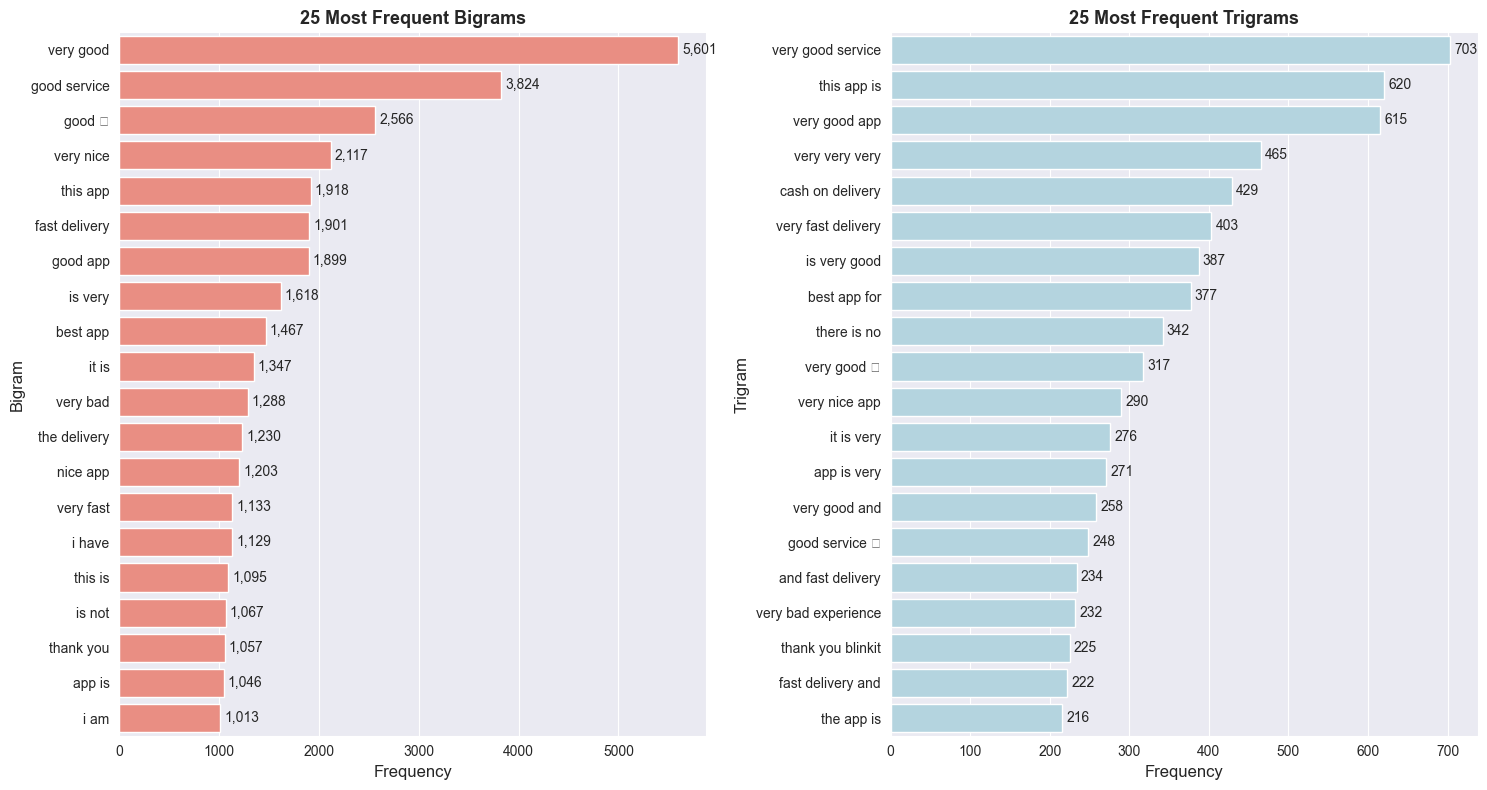

In [30]:
# Extracting N-Grams
raw_df["Tokens"] = raw_df["content"].str.lower().str.split()
bigram_freq, trigram_freq = Counter() , Counter()
for tokens in raw_df["Tokens"]:
    bigram_freq.update(ngrams(tokens, 2))
    trigram_freq.update(ngrams(tokens, 3))


# Number of n-grams to display
frequent_rank = 20

# Most frequent bigrams
most_frequent_bi_grams = bigram_freq.most_common(frequent_rank)
token_labels_bi_grams = [" ".join(gram) for gram, frequency in most_frequent_bi_grams]
token_frequency_bi_grams = [ frequency for gram, frequency in most_frequent_bi_grams]


# Most frequent trigrams
most_frequent_tri_grams = trigram_freq.most_common(frequent_rank)
token_labels_tri_grams = [" ".join(gram) for gram, frequency in most_frequent_tri_grams]
token_frequency_tri_grams = [ frequency for gram, frequency in most_frequent_tri_grams]


# Plotting
with sns.axes_style("darkgrid"):
    fig, ax = plt.subplots(1, 2, figsize=(15, 8))

    # Bigrams
    sns.barplot( x=token_frequency_bi_grams, y=token_labels_bi_grams, color="salmon", ax=ax[0]    )
    for container in ax[0].containers:
        ax[0].bar_label( container, fmt="{:,.0f}", padding=3, fontsize=10)
    ax[0].set_title( "25 Most Frequent Bigrams", fontsize=13, fontweight="bold")
    ax[0].set_ylabel("Bigram", fontsize=12)
    ax[0].set_xlabel("Frequency", fontsize=12)


    # Trigrams
    sns.barplot( x=token_frequency_tri_grams, y=token_labels_tri_grams, color="lightblue", ax=ax[1])
    for container in ax[1].containers:
        ax[1].bar_label( container, fmt="{:,.0f}", padding=3, fontsize=10)
    ax[1].set_title( "25 Most Frequent Trigrams", fontsize=13, fontweight="bold")
    ax[1].set_ylabel("Trigram", fontsize=12)
    ax[1].set_xlabel("Frequency", fontsize=12)

    plt.tight_layout()
    plt.show()

In [31]:
# Creating WordClouds based on Score

def create_score_wordcloud(df, score, text_column="content", score_column="score", width=1000, height=500):

    # Filter reviews by score
    filtered_df = df[df[score_column] == score]

    # Combine all review text
    text = " ".join(filtered_df[text_column].dropna().astype(str))

    # Generate word cloud
    wordcloud = WordCloud( width=width, height=height, max_words=150, stopwords=stop_words).generate(text)

    # Plot
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(
        f"Word Cloud - Score {score} "
        f"(n={len(filtered_df):,})",
        fontsize=16,
        fontweight="bold"
    )
    plt.show()

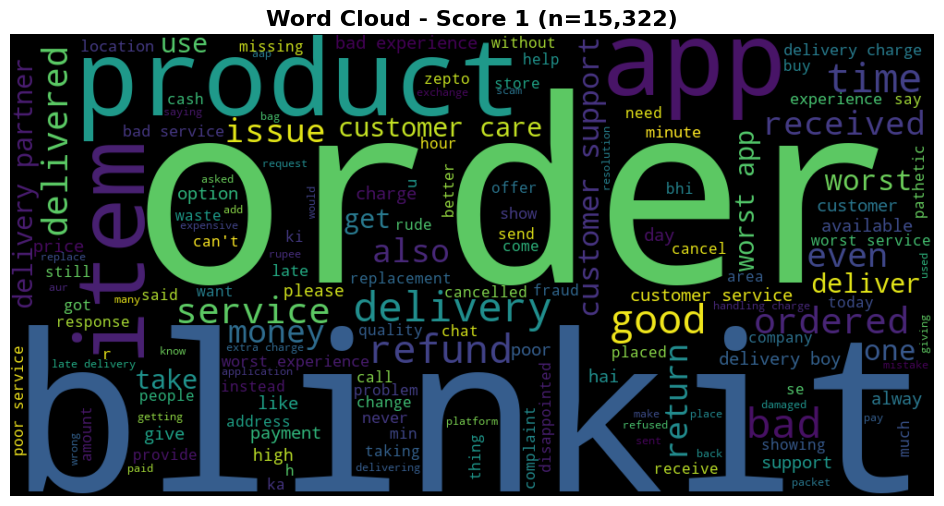

In [32]:
create_score_wordcloud(raw_df, 1)

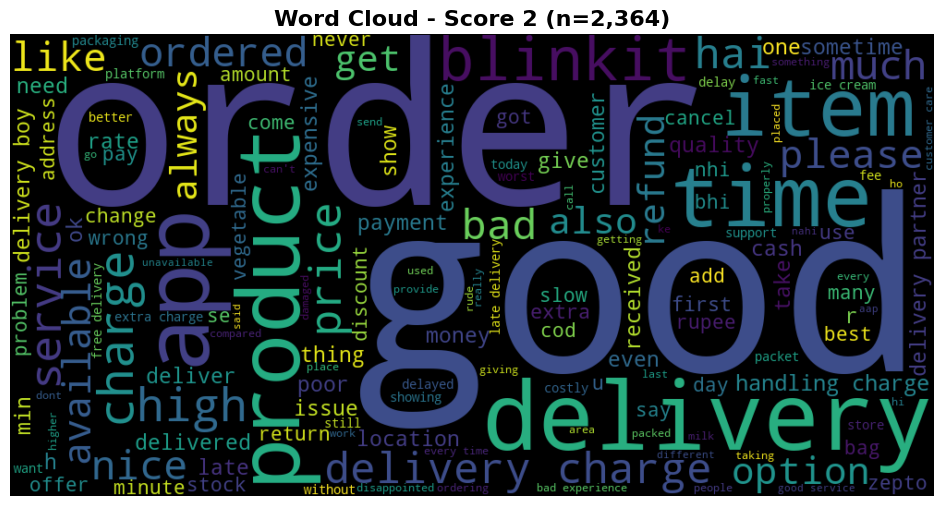

In [33]:
create_score_wordcloud(raw_df, 2)

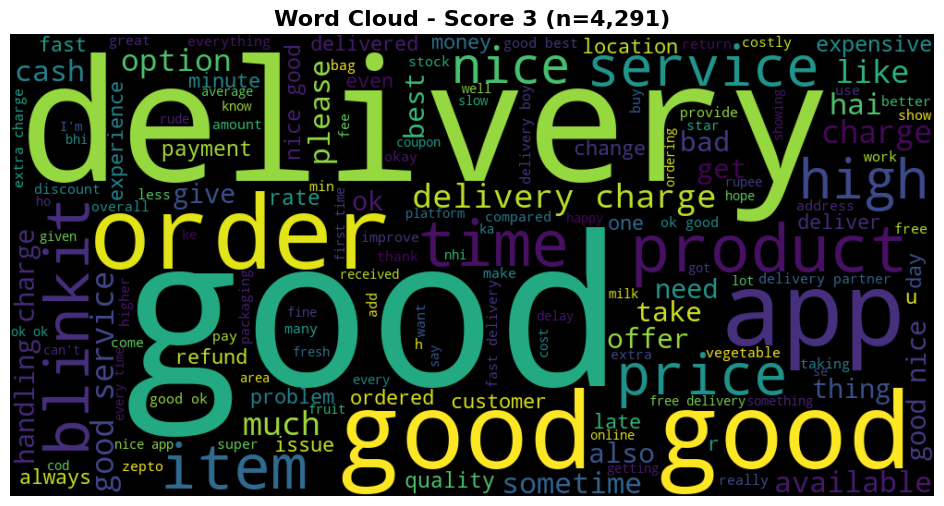

In [34]:
create_score_wordcloud(raw_df, 3)

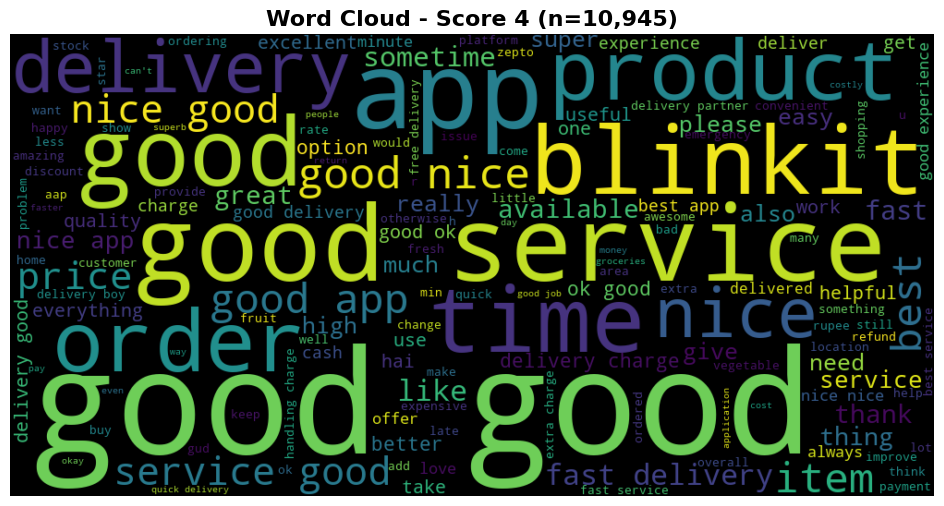

In [35]:
create_score_wordcloud(raw_df, 4)

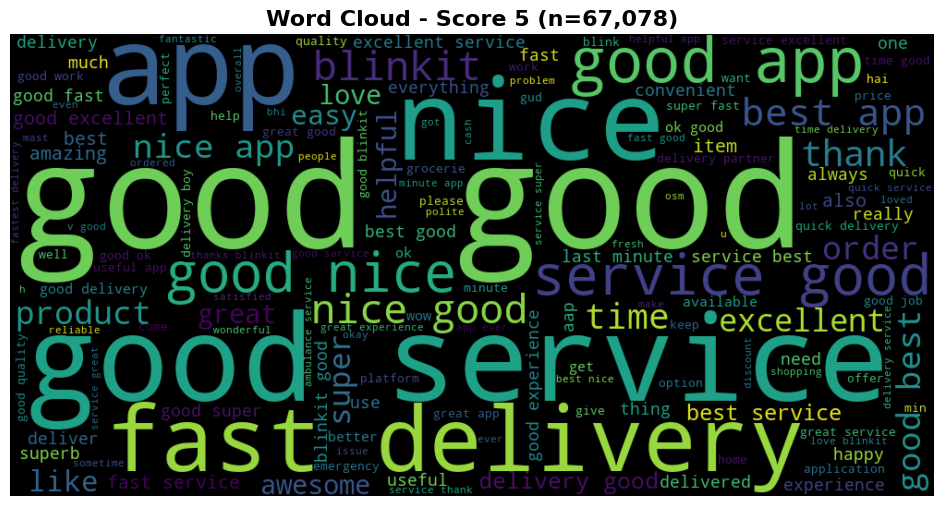

In [36]:
create_score_wordcloud(raw_df, 5)

##### Emoticon Analysis

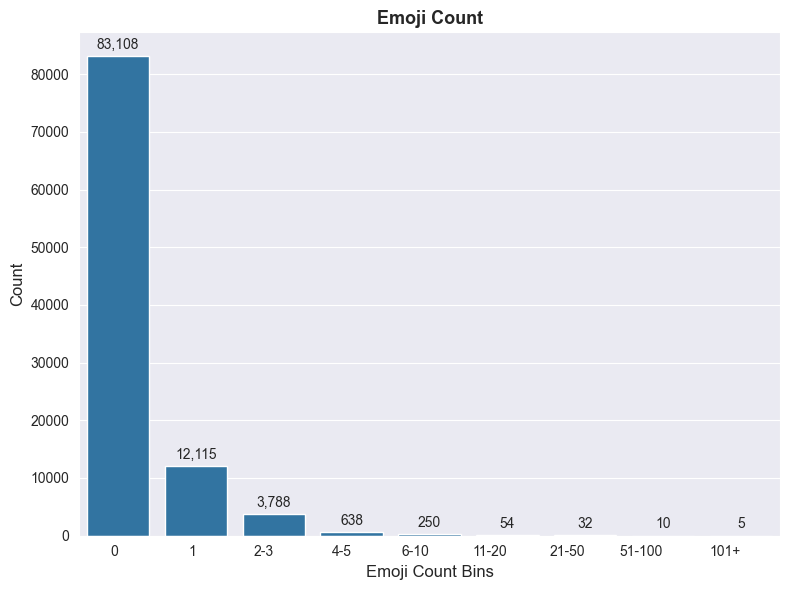

In [37]:
# Analyzing Emoticon usage in reviews
def count_emoji(input_text):
    """ 
    Function to calcualte the number of emojis used in input text.

    @returns:
    An integer value which denotes the number of emojis found in a review body
    
    """
    emojis = emoji.emoji_list(input_text)
    emoji_chars = [x["emoji"] for x in emojis]
    return len(emoji_chars)

raw_df['emoji_count'] = raw_df['content'].apply(lambda x : count_emoji(x))

# Binning number of emojis used 
bins = [-1, 0, 1, 3, 5, 10, 20, 50, 100, float("inf")]
labels = [ "0", "1", "2-3", "4-5", "6-10", "11-20", "21-50", "51-100", "101+"]
raw_df["emoji_bin"] = pd.cut( raw_df["emoji_count"], bins = bins, labels = labels)


with sns.axes_style('darkgrid'):
    plt.figure(figsize=(8, 6))
    ax = sns.countplot(data = raw_df, x = "emoji_bin")
    # Add data labels
    for container in ax.containers:
        ax.bar_label(container, fmt='{:,.0f}', padding=3, fontsize = 10) # type: ignore

    plt.title("Emoji Count", fontsize=13, fontweight="bold")
    plt.ylabel("Count", fontsize=12)
    plt.xlabel("Emoji Count Bins", fontsize=12)
    plt.xticks(rotation=0, ha="right")
    plt.tight_layout()
    plt.show()

In [38]:
# Summary Statistics of Emoji count by score
raw_df.groupby("emoji_bin", observed=True)["score"].agg(["count", "mean", "median"])

,count,mean,median
emoji_bin,,,
0,83108,4.038360,5.0
1,12115,4.542220,5.0
2-3,3788,4.523495,5.0
4-5,638,4.409091,5.0
6-10,250,4.300000,5.0
11-20,54,4.074074,5.0
21-50,32,4.062500,5.0
51-100,10,4.700000,5.0
101+,5,4.800000,5.0


`Emoji usage is associated with higher ratings`: Reviews with `1–3 emojis` have a `substantially higher mean rating` (~4.52–4.54) than `reviews without emojis` (4.04).
`Emoji frequency is not related to ratings`: Ratings `peak` at `1–3 emojis and generally decline with higher emoji counts`, although the high-emoji groups have very small sample sizes and should be interpreted cautiously.

## Exploratory Data Analysis - Conclusion

1. <u>Dataset Integrity and Missing Values</u> : The dataset contains 100,000 unique reviews (reviewId) with no duplicate records.

Key Stats:
* Complete coverage (0 missing) for primary fields like `content`, `score`, `userName`, `thumbsUpCount`, and `timestamps` (at).
* `reviewCreatedVersion` and appVersion each have 12,674 missing values (~12.67%).
* `replyContent` and `repliedAt` each have 1,539 missing values (~1.54%), indicating that ~98.46% of reviews received an official reply.

2. <u>Review Score Distribution & Satisfaction Skew</u>: Review ratings are heavily skewed toward high customer satisfaction.

Key Stats:
* 5-star ratings form the overwhelming majority, accounting for 73,382 reviews (73.38%).
* 1-star ratings represent the second-largest group with 15,487 reviews (15.49%).
* Intermediate scores (2, 3, and 4 stars) collectively make up only ~11.13% of all reviews, highlighting a clear polarization between highly satisfied users and dissatisfied users.

3. <u>Impact of Emojis on Ratings</u>: Moderate emoji usage in reviews strongly correlates with higher ratings.

Key Stats:
* Reviews containing 1 to 3 emojis have significantly higher mean ratings (~4.52 – 4.54) compared to reviews with no emojis (4.04 mean).
* High-frequency emoji usage (50+ emojis) shows lower sample sizes, but ratings generally peak around 1–3 emojis before tapering off.


4. <u>Thumbs Up Counts and Critical Feedback</u>: Higher thumbsUpCount values are heavily skewed toward critical (1-star and 2-star) reviews.

Key Stats:
* Out of the top reviews sorted by thumbsUpCount, lower-scored reviews (1-star) attract substantially more community agreement/likes (e.g., maximum thumbs-up counts reach over 1,400+ on negative reviews).
* This indicates that users actively upvote critical feedback pointing out bugs, payment issues, or poor customer service.


5. <u>Common Pain Points vs. Praise Themes (N-Grams & Keywords)</u> : Text analysis reveals distinct themes between positive and negative feedback.

Key Themes:
* Positive Reviews (5-star): Characterized by short praise phrases such as "very useful", "very good app", and "nice delivery".
* Negative Reviews (1-star & 2-star): Dominated by complaints surrounding core transactional functionality, specifically "payment and refund system", "poor service", and "delivery issues".